In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
# Read in initial data files
df_energy = pd.read_csv('data/raw/energy_dataset.csv')
df_weather = pd.read_csv('data/raw/weather_features.csv')

# Convert date/time to datetime format
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True)
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True)

# Extract date and hour for each dataframe
df_energy.insert(1, 'date', df_energy['time'].dt.date)
df_energy.insert(2, 'hour', df_energy['time'].dt.hour)

df_weather.insert(1, 'date', df_weather['dt_iso'].dt.date)
df_weather.insert(2, 'hour', df_weather['dt_iso'].dt.hour)

# Rename weather column
df_weather = df_weather.rename(columns={'dt_iso': 'time'})

In [27]:
df_energy.shape

(35064, 31)

In [15]:
# Print information on weather dataset
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   time                 178396 non-null  datetime64[us, UTC]
 1   date                 178396 non-null  object             
 2   hour                 178396 non-null  int32              
 3   city_name            178396 non-null  str                
 4   temp                 178396 non-null  float64            
 5   temp_min             178396 non-null  float64            
 6   temp_max             178396 non-null  float64            
 7   pressure             178396 non-null  int64              
 8   humidity             178396 non-null  int64              
 9   wind_speed           178396 non-null  int64              
 10  wind_deg             178396 non-null  int64              
 11  rain_1h              178396 non-null  float64            
 12  rain_3h      

In [16]:
# Drop columns with string descriptions of weather and weather ID. Model will only take in numerical input as features
df_weather = df_weather.drop(columns=['weather_id', 'weather_main', 'weather_description', 'weather_icon'])

# Eliminate any leading or trailing spaces for city name strings
df_weather['city_name'] = df_weather['city_name'].str.strip()

In [29]:
# Identify any duplicated data
dup_rows = df_weather[df_weather.duplicated(keep=False)]
dup_rows

# Drop duplicate rows for cities since numerical values are the same
df_weather_clean = df_weather.drop_duplicates(keep='first').reset_index(drop=True)
df_weather_clean

# Print the number of rows of data per city
print(f'Data Rows per City:')
print(df_weather_clean.groupby('city_name').size())
print(f'\nData Rows in Energy df: {df_energy.shape[0]}')

Data Rows per City:
city_name
Barcelona    35064
Bilbao       35064
Madrid       35064
Seville      35064
Valencia     35064
dtype: int64

Data Rows in Energy df: 35064


In [31]:
# Determine how many null values are in the dataframe
df_weather.isnull().sum()

time          0
date          0
hour          0
city_name     0
temp          0
temp_min      0
temp_max      0
pressure      0
humidity      0
wind_speed    0
wind_deg      0
rain_1h       0
rain_3h       0
snow_3h       0
clouds_all    0
dtype: int64

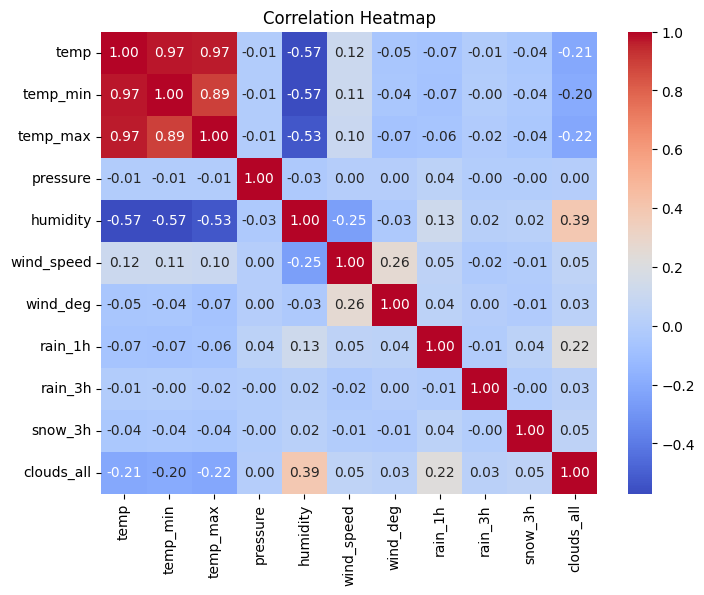

In [34]:
# Perform a correlation analysis across remaining features to drop any features that are highly correlated
df_corr = df_weather_clean.drop(columns=['time', 'date', 'hour', 'city_name'])
corr = df_corr.corr(method='pearson')

# Plot the correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [47]:
# Select upper triangle of correlation matrix
upper = corr.abs().where(
    np.triu(np.ones(corr.abs().shape), k=1).astype(bool)
)

# Find columns with correlation > 0.75
to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]

print('Columns to drop:')
print(to_drop)

# Drop highly correlated columns
df_weather_filter = df_weather_clean.drop(columns=to_drop)

# Convert temperature (K) to Celsius
df_weather_filter['temp'] = df_weather_filter['temp'] - 273.15

Columns to drop:
['temp_min', 'temp_max']


In [51]:
df_weather_filter

,time,date,hour,city_name,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,2014-12-31,23,Valencia,-2.675,1001,77,1,62,0.0,0.0,0.0,0
1,2015-01-01 00:00:00+00:00,2015-01-01,0,Valencia,-2.675,1001,77,1,62,0.0,0.0,0.0,0
2,2015-01-01 01:00:00+00:00,2015-01-01,1,Valencia,-3.464,1002,78,0,23,0.0,0.0,0.0,0
3,2015-01-01 02:00:00+00:00,2015-01-01,2,Valencia,-3.464,1002,78,0,23,0.0,0.0,0.0,0
4,2015-01-01 03:00:00+00:00,2015-01-01,3,Valencia,-3.464,1002,78,0,23,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175315,2018-12-31 18:00:00+00:00,2018-12-31,18,Seville,14.610,1028,54,3,30,0.0,0.0,0.0,0
175316,2018-12-31 19:00:00+00:00,2018-12-31,19,Seville,12.610,1029,62,3,30,0.0,0.0,0.0,0
175317,2018-12-31 20:00:00+00:00,2018-12-31,20,Seville,12.000,1028,58,4,50,0.0,0.0,0.0,0
175318,2018-12-31 21:00:00+00:00,2018-12-31,21,Seville,11.000,1029,57,4,60,0.0,0.0,0.0,0


In [49]:
# Pivot the weather table to wide format (i.e. temp_Valencia, temp_Bilbao, temp_Seville, etc.)

# Keep the temporal id columns
id_cols = ['time', 'date', 'hour']

# Pivot the dataframe
df_weather_wide = df_weather_filter.pivot(
    index=id_cols,
    columns='city_name'
)

# Flatten multi-level column names
df_weather_wide.columns = [
    f"{feature}_{city}"
    for feature, city in df_weather_wide.columns
]

# Change index columns back to normal columns
df_wide = df_weather_wide.reset_index()

In [50]:
df_wide

,time,date,hour,temp_Barcelona,temp_Bilbao,temp_Madrid,temp_Seville,temp_Valencia,pressure_Barcelona,pressure_Bilbao,...,snow_3h_Barcelona,snow_3h_Bilbao,snow_3h_Madrid,snow_3h_Seville,snow_3h_Valencia,clouds_all_Barcelona,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Seville,clouds_all_Valencia
0,2014-12-31 23:00:00+00:00,2014-12-31,23,8.475,-3.492687,-5.825,0.225,-2.675,1035,1036,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
1,2015-01-01 00:00:00+00:00,2015-01-01,0,8.475,-3.386500,-5.825,0.225,-2.675,1035,1035,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
2,2015-01-01 01:00:00+00:00,2015-01-01,1,8.136,-3.898312,-6.964,0.936,-3.464,1036,1036,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
3,2015-01-01 02:00:00+00:00,2015-01-01,2,8.136,-3.946656,-6.964,0.936,-3.464,1036,1035,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
4,2015-01-01 03:00:00+00:00,2015-01-01,3,8.136,-3.664500,-6.964,0.936,-3.464,1036,1035,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 18:00:00+00:00,2018-12-31,18,10.980,8.110000,10.410,14.610,12.490,1027,1033,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35060,2018-12-31 19:00:00+00:00,2018-12-31,19,9.490,6.660000,6.970,12.610,9.990,1027,1034,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35061,2018-12-31 20:00:00+00:00,2018-12-31,20,8.990,4.000000,5.000,12.000,8.510,1028,1034,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
35062,2018-12-31 21:00:00+00:00,2018-12-31,21,7.980,3.450000,3.420,11.000,6.990,1028,1034,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0


In [ ]:
# Columns that uniquely identify each timestamp
id_cols = ['time', 'date', 'hour']

# Pivot the dataframe
df_wide = df.pivot(
    index=id_cols,
    columns='city_name'
)

# Flatten multi-level column names
df_wide.columns = [
    f"{feature}_{city}"
    for feature, city in df_wide.columns
]

# Move index columns back to normal columns
df_wide = df_wide.reset_index()

print(df_wide.head())

In [38]:
df_weather_filter

,time,date,hour,city_name,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,2014-12-31,23,Valencia,270.475,1001,77,1,62,0.0,0.0,0.0,0
1,2015-01-01 00:00:00+00:00,2015-01-01,0,Valencia,270.475,1001,77,1,62,0.0,0.0,0.0,0
2,2015-01-01 01:00:00+00:00,2015-01-01,1,Valencia,269.686,1002,78,0,23,0.0,0.0,0.0,0
3,2015-01-01 02:00:00+00:00,2015-01-01,2,Valencia,269.686,1002,78,0,23,0.0,0.0,0.0,0
4,2015-01-01 03:00:00+00:00,2015-01-01,3,Valencia,269.686,1002,78,0,23,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175315,2018-12-31 18:00:00+00:00,2018-12-31,18,Seville,287.760,1028,54,3,30,0.0,0.0,0.0,0
175316,2018-12-31 19:00:00+00:00,2018-12-31,19,Seville,285.760,1029,62,3,30,0.0,0.0,0.0,0
175317,2018-12-31 20:00:00+00:00,2018-12-31,20,Seville,285.150,1028,58,4,50,0.0,0.0,0.0,0
175318,2018-12-31 21:00:00+00:00,2018-12-31,21,Seville,284.150,1029,57,4,60,0.0,0.0,0.0,0


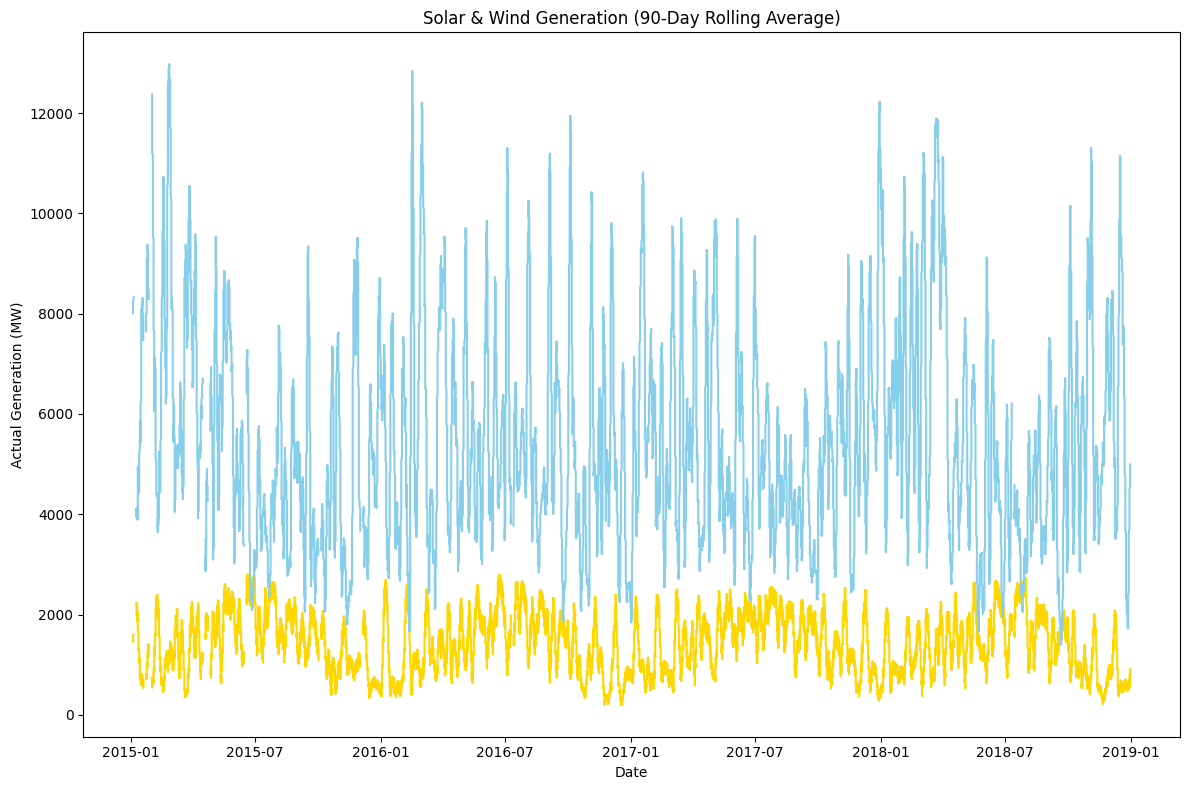

In [ ]:
# Visualize initial renewable generation
# Create 90-day rolling average of generation
df_energy['solar_rolling'] = df_energy['generation solar'].rolling(window=90).mean()
df_energy['wind_rolling'] = df_energy['generation wind onshore'].rolling(window=90).mean()

# Define x-axis dataset
date = df_energy['date']

fig, ax = plt.subplots(figsize=(12,8))
# ax.plot(date, df_energy['generation solar'], color='gold', alpha=0.4)
ax.plot(date, df_energy['solar_rolling'], color='gold')
# ax.plot(date, df_energy['generation wind onshore'], color='skyblue', alpha=0.4)
ax.plot(date, df_energy['wind_rolling'], color='skyblue')

# Customize the plot
ax.set_xlabel('Date')
ax.set_ylabel('Actual Generation (MW)')
ax.set_title('Solar & Wind Generation (90-Day Rolling Average)')

plt.tight_layout()
plt.show()